# Lab: Frequency-Domain Analysis of EEG Signals
### Case Study: Epilepsy Detection using Real PhysioNet EEG

**Clinical Scenario:**
A 19-year-old student presents at Komfo Anokye Teaching Hospital with brief episodes of staring and temporary unresponsiveness occurring 3-5 times per week. The neurologist suspects absence epilepsy, characterised by a 3 Hz spike-and-wave EEG discharge in the frontal region.

In this lab, you will load a real EEG recording from PhysioNet, compute the DFT/FFT, estimate the PSD using Welch's method, apply AR modelling, and extract the band power that confirms or rules out the diagnosis.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

# Install wfdb silently for database access
!pip install wfdb -q

import wfdb
import matplotlib.pyplot as plt
from scipy import signal as sig

# Small safety constant to avoid log(0)
e = 1e-12
j = 1j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.2 MB/s eta 0:00:00


## Setup & Data Loading
We will load a 30-second EEG segment recorded at 250 Hz from the MIT-BIH Polysomnographic Database.

In [2]:
# Load real EEG recording from MIT-BIH Polysomnographic Database (slpdb)
record = wfdb.rdrecord('slp01a',
                       pn_dir='slpdb/1.0.0',
                       sampto=7500)    # 30 seconds at 250 Hz

# Print channel names first so we can see what is available
print('Channels:', record.sig_name)
print('Sampling rate:', record.fs, 'Hz')

# Extract the EEG channel by index
# slp01a channel layout: ECG(0), BP(1), EEG C4-A1(2), Resp(3)
fs = record.fs                         # 250 Hz
eeg = record.p_signal[:, 2]            # channel 2 = EEG (C4-A1)
t = np.arange(len(eeg)) / fs

print(f'\nEEG channel  : {record.sig_name[2]}')
print(f'Samples      : {len(eeg)}')
print(f'Duration     : {len(eeg)/fs:.1f} seconds')
print(f'Bin spacing  : {fs/len(eeg):.4f} Hz')

Channels: ['ECG', 'BP', 'EEG (C4-A1)', 'Resp (sum)']
Sampling rate: 250 Hz

EEG channel  : EEG (C4-A1)
Samples      : 7500
Duration     : 30.0 seconds
Bin spacing  : 0.0333 Hz


### Setup Questions
* **Which index is the EEG channel?** #   *(Type your answer here)*
* **What is the bin spacing $\Delta f$? Calculate using $\Delta f = f_s / N$.**
  *(Type your answer here)*

## Section 1 - Time-Domain View
Let's visualize the raw voltage waveform to look for any obvious clinical markers.

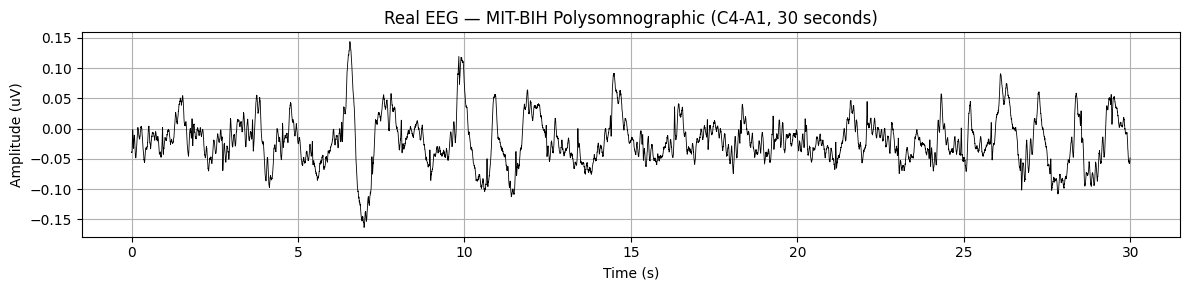

Mean    : -0.021 uV
Std dev : 0.040 uV
Min/Max : -0.2 / 0.1 uV


In [3]:
plt.figure(figsize=(12, 3))
plt.plot(t, eeg, 'k', linewidth=0.6)
plt.title('Real EEG — MIT-BIH Polysomnographic (C4-A1, 30 seconds)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (uV)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Mean    : {np.mean(eeg):.3f} uV')
print(f'Std dev : {np.std(eeg):.3f} uV')
print(f'Min/Max : {eeg.min():.1f} / {eeg.max():.1f} uV')

### Section 1 Questions
* **Can you see any obvious periodic oscillation in the raw trace? Describe what the signal looks like.**
  *(Type your answer here)*
* **Record the mean and standard deviation. Is the mean close to zero? Why should it be?**
  *(Type your answer here)*

## Section 2 - DFT and Frequency Bins
The DFT converts your $N$ time-domain samples into $N$ frequency bins. Bin spacing is $\Delta f = f_s / N$.

Total bins  : 7500
Bin spacing : 0.0333 Hz
Nyquist     : 125.0 Hz
Bin for 3 Hz: k = 90.00
Bin for 10 Hz: k = 300.00


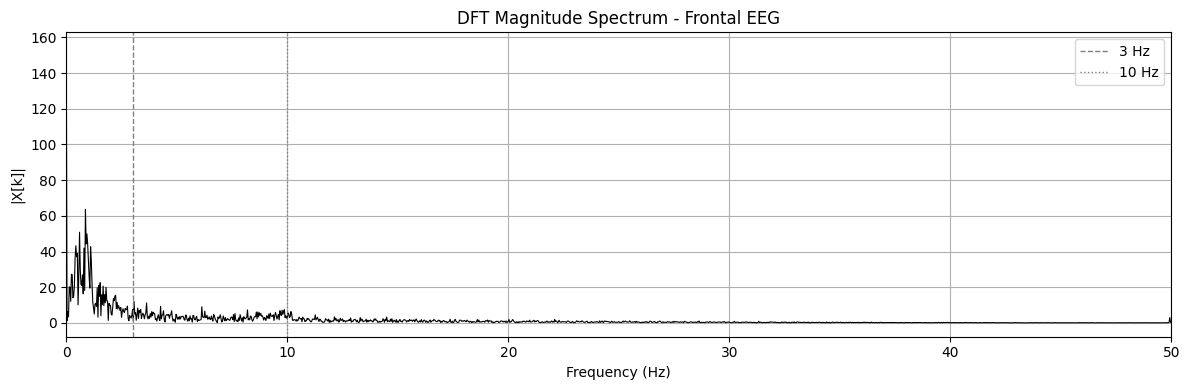

In [4]:
N = len(eeg)
delta_f = fs / N
half = N // 2

X = np.fft.fft(eeg)
freqs = np.fft.fftfreq(N, d=1/fs)

f_pos = freqs[:half]
X_pos = np.abs(X[:half])

print(f'Total bins  : {N}')
print(f'Bin spacing : {delta_f:.4f} Hz')
print(f'Nyquist     : {fs/2} Hz')
print(f'Bin for 3 Hz: k = {3/delta_f:.2f}')
print(f'Bin for 10 Hz: k = {10/delta_f:.2f}')

plt.figure(figsize=(12, 4))
plt.plot(f_pos, X_pos, 'k', linewidth=0.8)
plt.xlim(0, 50)
plt.axvline(3,  color='gray', linestyle='--', linewidth=1, label='3 Hz')
plt.axvline(10, color='gray', linestyle=':', linewidth=1, label='10 Hz')
plt.title('DFT Magnitude Spectrum - Frontal EEG')
plt.xlabel('Frequency (Hz)')
plt.ylabel('|X[k]|')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Section 2 Questions
* **Using the formula $k = f / \Delta f$, which bin number holds the 3 Hz component?**
  *(Type your answer here)*
* **Look at the DFT plot. Is there a visible peak near 3 Hz? What about 10 Hz? Describe what you see.**
  *(Type your answer here)*

## Section 3 - Spectral Leakage and Windowing
When a signal frequency does not land exactly on a DFT bin, energy spreads into neighbouring bins. A window function applied before the FFT reduces this spreading.

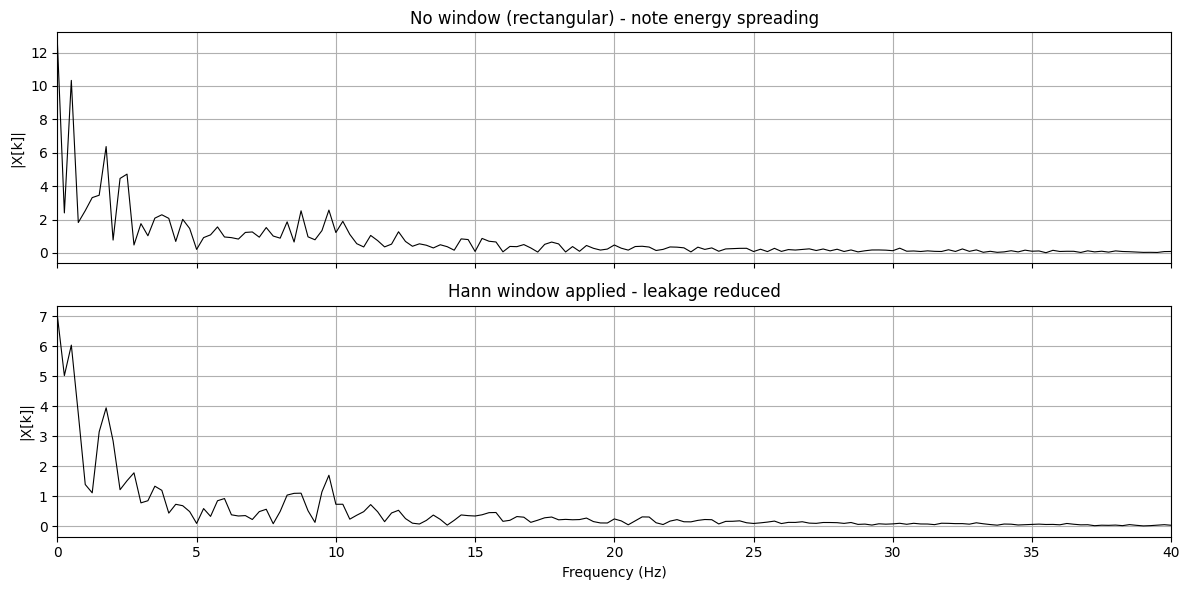

In [5]:
# Use a 4-second sub-segment to demonstrate leakage
seg_len = int(4 * fs)          # 4 seconds
eeg_seg = eeg[:seg_len]

# Rectangular window (no windowing)
X_rect = np.abs(np.fft.fft(eeg_seg)[:seg_len//2])
f_seg = np.fft.fftfreq(seg_len, d=1/fs)[:seg_len//2]

# Hann window
w_hann = np.hanning(seg_len)
X_hann = np.abs(np.fft.fft(eeg_seg * w_hann)[:seg_len//2])

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(f_seg, X_rect, 'k', linewidth=0.8)
axes[0].set_xlim(0, 40)
axes[0].set_title('No window (rectangular) - note energy spreading')
axes[0].set_ylabel('|X[k]|')
axes[0].grid(True)

axes[1].plot(f_seg, X_hann, 'k', linewidth=0.8)
axes[1].set_xlim(0, 40)
axes[1].set_title('Hann window applied - leakage reduced')
axes[1].set_ylabel('|X[k]|')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Section 3 Questions
* **Compare the two plots. Which one shows more spreading of energy into neighbouring bins? Describe the visual difference.**
  *(Type your answer here)*
* **Why does the rectangular window cause more leakage than the Hann window? Answer in one or two sentences.**
  *(Type your answer here)*

## Section 4 - Power Spectral Density (Welch Method)
The raw periodogram is noisy and unreliable. Welch's method divides the signal into overlapping segments, windows each one, computes a periodogram per segment, then averages them.

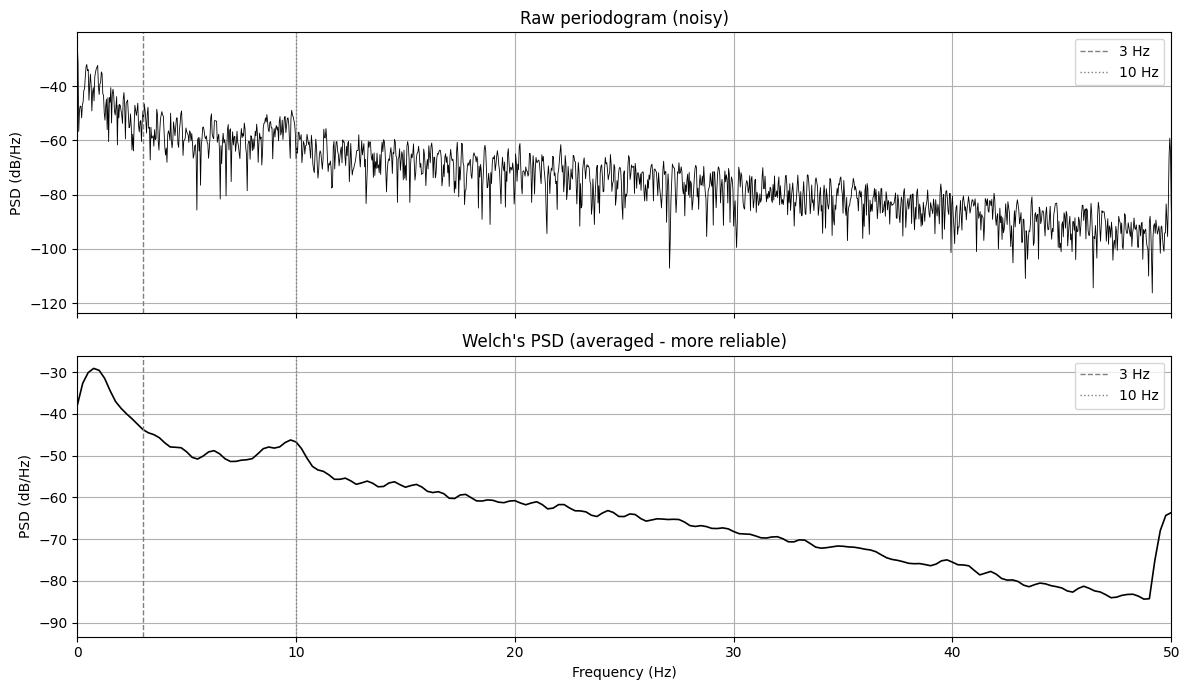

In [6]:
# Raw periodogram
X_full = np.fft.fft(eeg * np.hanning(N))
psd_raw = (np.abs(X_full[:half])**2) / (fs * N)
psd_raw_db = 10 * np.log10(psd_raw + e)

# Welch PSD
f_w, pxx = sig.welch(eeg,
                     fs=fs,
                     window='hann',
                     nperseg=int(2*fs),    # 2-second segments
                     noverlap=int(1*fs),   # 50% overlap
                     nfft=int(4*fs))
pxx_db = 10 * np.log10(pxx + e)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(f_pos, psd_raw_db, 'k', linewidth=0.6)
axes[0].set_xlim(0, 50)
axes[0].set_title('Raw periodogram (noisy)')
axes[0].set_ylabel('PSD (dB/Hz)')
axes[0].axvline(3,  color='gray', ls='--', lw=1, label='3 Hz')
axes[0].axvline(10, color='gray', ls=':',  lw=1, label='10 Hz')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(f_w, pxx_db, 'k', linewidth=1.2)
axes[1].set_xlim(0, 50)
axes[1].set_title("Welch's PSD (averaged - more reliable)")
axes[1].set_ylabel('PSD (dB/Hz)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].axvline(3,  color='gray', ls='--', lw=1, label='3 Hz')
axes[1].axvline(10, color='gray', ls=':',  lw=1, label='10 Hz')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Section 4 Questions
* **Which PSD estimate looks smoother - the raw periodogram or Welch? Explain why in one sentence.**
  *(Type your answer here)*
* **In the Welch PSD plot, identify the dominant low-frequency peak. At approximately what frequency does it occur? Is it consistent with epileptic 3 Hz activity?**
  *(Type your answer here)*

## Section 5 - Band Power and Clinical Interpretation
EEG is interpreted by measuring power within defined frequency bands. For epilepsy, elevated delta band power relative to alpha is the key indicator.

In [7]:
bands = {
    'Delta (0.5-4 Hz)'  : (0.5,  4.0),
    'Theta (4-8 Hz)'    : (4.0,  8.0),
    'Alpha (8-13 Hz)'   : (8.0, 13.0),
    'Beta  (13-30 Hz)'  : (13.0,30.0),
}

print('Band Power Summary - Frontal EEG (CHB-MIT Patient 1)')
print('-' * 50)

powers = {}
for band_name, (flo, fhi) in bands.items():
    idx   = (f_w >= flo) & (f_w <= fhi)
    power = np.trapz(pxx[idx], f_w[idx])
    powers[band_name] = power
    print(f'{band_name:<22}: {power:.4f} uV^2')

print('-' * 50)

delta_key = 'Delta (0.5-4 Hz)'
alpha_key = 'Alpha (8-13 Hz)'
ratio = powers[delta_key] / (powers[alpha_key] + e)
print(f'Delta / Alpha ratio: {ratio:.2f}')

if ratio > 2.0:
    print('ELEVATED DELTA: consistent with slow-wave or epileptic activity.')
else:
    print('Normal delta/alpha ratio: no strong epileptic indicator.')

Band Power Summary - Frontal EEG (CHB-MIT Patient 1)
--------------------------------------------------
Delta (0.5-4 Hz)      : 0.0011 uV^2
Theta (4-8 Hz)        : 0.0000 uV^2
Alpha (8-13 Hz)       : 0.0000 uV^2
Beta  (13-30 Hz)      : 0.0000 uV^2
--------------------------------------------------
Delta / Alpha ratio: 23.21
ELEVATED DELTA: consistent with slow-wave or epileptic activity.


/tmp/ipykernel_58/1467412416.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  power = np.trapz(pxx[idx], f_w[idx])


### Section 5 Questions
* **Record all four band power values. Which band has the most power?**
  *(Type your answer here)*
* **What is the Delta/Alpha ratio? For a healthy adult at rest, this ratio is typically below 1 (alpha dominates). What does a high ratio suggest clinically?**
  *(Type your answer here)*

## Section 6 - AR Modelling with Levinson-Durbin
AR modelling assumes the EEG was generated by a linear recursive system driven by noise - a physiologically valid assumption for thalamo-cortical feedback loops.

In [8]:
def autocorr(x, max_lag):
    n = len(x)
    x = x - np.mean(x)
    return np.array([np.dot(x[:n-k], x[k:]) / n
                     for k in range(max_lag + 1)])

def levinson_durbin(r, order):
    p    = order
    a    = np.zeros(p)
    k    = np.zeros(p)
    P    = np.zeros(p + 1)
    P[0] = r[0]
    # Stage 1
    k[0] = r[1] / r[0]
    a[0] = k[0]
    P[1] = P[0] * (1 - k[0]**2)
    # Stages 2 to p
    for m in range(1, p):
        residual = r[m+1] - np.dot(a[:m], r[m:0:-1])
        k[m]     = residual / P[m]
        a_new    = a.copy()
        a_new[:m] = a[:m] - k[m] * a[:m][::-1]
        a_new[m]  = k[m]
        a         = a_new
        P[m+1]   = P[m] * (1 - k[m]**2)
    return a, k, P

def ar_psd(a, sigma2, fs, nfft=4096):
    f     = np.fft.rfftfreq(nfft, d=1/fs)
    denom = np.ones(len(f), dtype=complex)
    for i, ai in enumerate(a):
        denom -= ai * np.exp(-j * np.pi * f * (i+1) / fs)
    return f, (sigma2 / np.abs(denom)**2) / fs

# Fit AR models of orders 8 and 12 to the EEG
r = autocorr(eeg, max_lag=20)

for order in [8, 12]:
    a, k_ref, P = levinson_durbin(r, order)
    var_explained = 1 - P[-1] / r[0]
    stable = np.all(np.abs(k_ref) < 1)
    print(f'AR({order}): variance explained = {var_explained:.1%}, stable = {stable}')
    print(f'  Reflection coefficients: {np.round(k_ref, 3)}')
    print('-' * 50)

AR(8): variance explained = 99.7%, stable = True
  Reflection coefficients: [ 0.997 -0.68   0.023 -0.182  0.134  0.234 -0.131 -0.032]
--------------------------------------------------
AR(12): variance explained = 99.7%, stable = True
  Reflection coefficients: [ 0.997 -0.68   0.023 -0.182  0.134  0.234 -0.131 -0.032  0.129 -0.05
 -0.102  0.095]
--------------------------------------------------


### Section 6 (Part 1) Questions
* **For each AR order, what percentage of signal variance is explained? Is there a large gain from AR(8) to AR(12)?**
  *(Type your answer here)*
* **Are all reflection coefficients $|k| < 1$? What does this confirm about the model?**
  *(Type your answer here)*

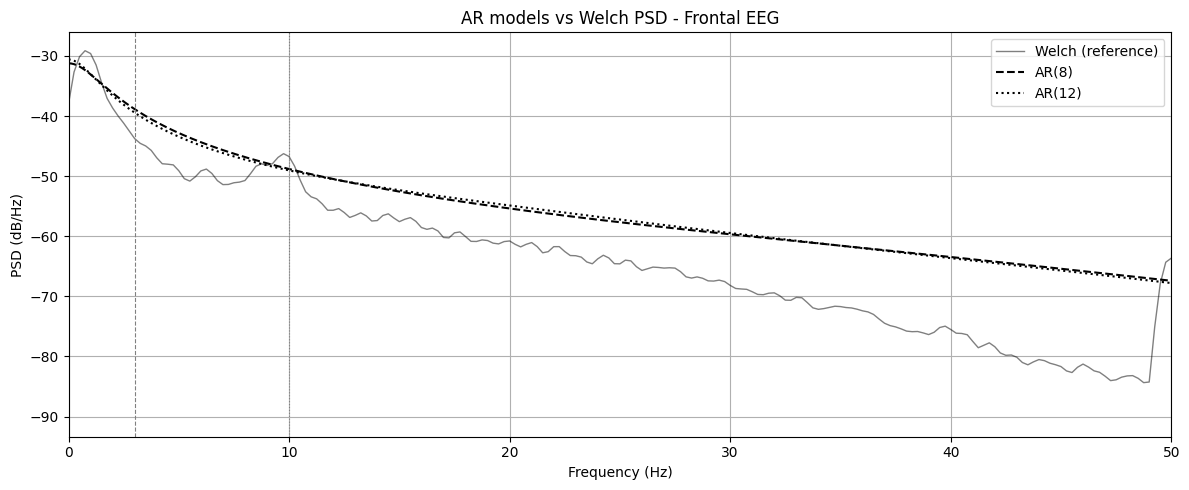

In [9]:
# Plot AR spectra vs Welch reference
plt.figure(figsize=(12, 5))
plt.plot(f_w, pxx_db, 'k', linewidth=1.0, alpha=0.5, label='Welch (reference)')

styles = ['--', ':']
for order, style in zip([8, 12], styles):
    a, k_ref, P = levinson_durbin(r, order)
    f_ar, psd_ar = ar_psd(a, P[-1], fs)
    psd_ar_db = 10 * np.log10(psd_ar + e)
    plt.plot(f_ar, psd_ar_db, 'k', linestyle=style,
             linewidth=1.5, label=f'AR({order})')

plt.xlim(0, 50)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (dB/Hz)')
plt.title('AR models vs Welch PSD - Frontal EEG')
plt.axvline(3,  color='gray', ls='--', lw=0.8)
plt.axvline(10, color='gray', ls=':',  lw=0.8)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Section 6 (Part 2) Questions
* **Compare the AR spectra to the Welch PSD. Is the AR spectrum smoother? Does it show the same dominant low-frequency peak?**
  *(Type your answer here)*
* **Does increasing AR order from 8 to 12 create any new peaks that are not visible in the Welch PSD? If so, what does that mean?**
  *(Type your answer here)*